In [1]:
import diffrax
import jax.numpy as jnp
import numpy as np

import scipy.integrate as sci
import matplotlib.pyplot as plt

# Define the parameters used for both solvers

In [2]:
# Parameters for the predator/prey system
alpha = 0.67  # Birth rate of rabbits (1/d)
beta = 1.33  # Death rate of rabbits (1/d per 1000 foxes)
gamma = 1.00  # Birth rate of foxes (1/d per 1000 rabbits)
delta = 1.00  # Death rate of foxes (1/d)

# Initial conditions
x0 = 1.00  # Initial number of rabbits (1000s)
y0 = 0.75  # Initial number of foxes (1000s)

# simulation time
t0 = 0.0  # Start time (days)
t_end = 50.0  # End time (days)

## Diffrax

Solve using the `diffrax` and `jax` methods


The `lotka_volterra` model is very similar between both methods except the final array must be `jnp.array` for `diffrax` and `np.array` for `odeint`. Also, `odeint` passes arguments to `lotka_volterra` unpacked while `diffrax` does not.

In [29]:
def lotka_volterra_jax(t, y_in, args):
    alpha, beta, gamma, delta = args
    x, y = y_in
    dxdt = alpha * x - beta * x * y
    dydt = gamma * x * y - delta * y
    return jnp.array([dxdt, dydt])

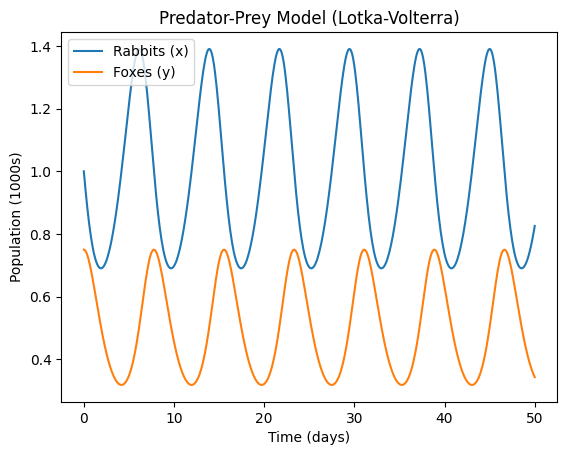

In [ ]:
ode_term = diffrax.ODETerm(lotka_volterra_jax)

# Initial state
y_init = jnp.array([x0, y0])

# Solver configuration
solver = diffrax.Dopri5()
saveat = diffrax.SaveAt(ts=jnp.linspace(t0, t_end, 500))

# Solve the ODE
solution = diffrax.diffeqsolve(
    ode_term,
    solver,
    t0=t0,
    t1=t_end,
    dt0=0.1,
    y0=y_init,
    args=(alpha, beta, gamma, delta),  # Pass parameters as args
    saveat=saveat,
)

# Plot the results
plt.plot(solution.ts, solution.ys[:, 0], label="Rabbits (x)")
plt.plot(solution.ts, solution.ys[:, 1], label="Foxes (y)")
plt.xlabel("Time (days)")
plt.ylabel("Population (1000s)")
plt.legend()
plt.title("Predator-Prey Model (Lotka-Volterra)")
plt.show()
               

## solve_ivp

**Update 5/12/2025**: Change to `scipy.integrate.solve_ivp` for `scipy` models to use best practices for scipy integration models.


Now solve again using `scipy.integrate.solve_ivp`. Everything stays the same except the output from the method is a numpy array.

In [3]:
def lotka_volterra_sci(t, y_in, alpha, beta, gamma, delta):
    x, y = y_in
    dxdt = alpha * x - beta * x * y
    dydt = gamma * x * y - delta * y
    return np.array([dxdt, dydt])

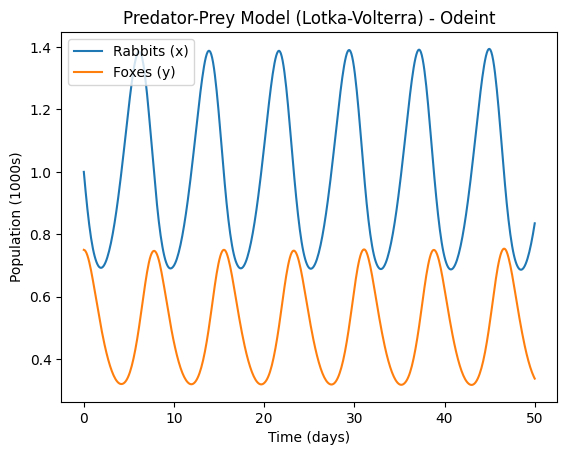

In [9]:
# Time points for the simulation
time_points = np.linspace(t0, t_end, 500)

y_init = np.array([x0, y0])
t_span = np.array([time_points[0], time_points[-1]])

# Solve the ODE using odeint
solution_sci = sci.solve_ivp(
    fun=lotka_volterra_sci,
    t_span=t_span,
    y0=y_init,  # Initial conditions
    t_eval=time_points,  # Time points
    args=(alpha, beta, gamma, delta),
)

# Plot the results
plt.plot(solution_sci.t, solution_sci.y[0], label="Rabbits (x)")
plt.plot(solution_sci.t,  solution_sci.y[1], label="Foxes (y)")
plt.xlabel("Time (days)")
plt.ylabel("Population (1000s)")
plt.legend()
plt.title("Predator-Prey Model (Lotka-Volterra) - Odeint")
plt.show()

# Main Differences

1. `odeint` uses `np.array` while `diffrax` uses `jnp.array`
2. `odeint` unpacks passed in arguments while `diffrax` does not.
    - Ultimately, we probably want to have this built in method use class attrbutes instead of passing arguments to the solver.

# Solve a 1-compartment PK model

Using the model structure from pk1.model

In [10]:
Vd = 50    # Volume of distribution (L).
k01 = 1    # Absorption rate (h^{-1}).
k12 = 0.5; # Clearance rate (h^{-1}).
MW = 150;  # Molecular weight (g/mol).

In [11]:
def pk1_model(t, y_in, k01, k12, Vd):
    A0, A1, A2, AUC = y_in
    C = A1 / Vd
    dA0dt = -k01 * A0
    dA1dt = k01 * A0 - k12 * A1
    dA2dt = k12 * A1
    dAUCdt = (A1 + A2) / Vd
    return np.array([dA0dt, dA1dt, dA2dt, dAUCdt])

/data/tzurlind/tmp/ipykernel_814366/449072910.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


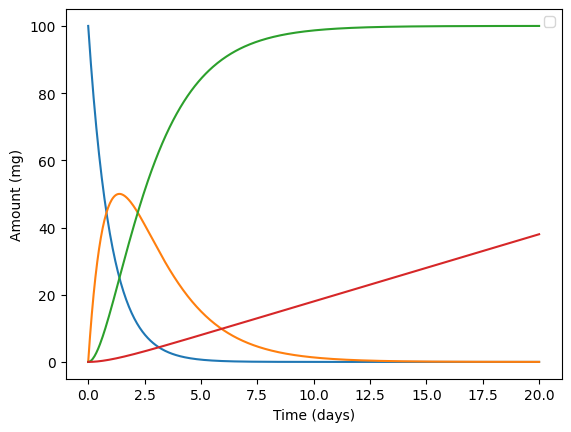

In [14]:
# Time points for the simulation
time_points = np.linspace(0, 20, 500)

y_init = np.array([100, 0, 0, 0])
t_span = np.array([time_points[0], time_points[-1]])

# Solve the ODE using odeint
solution_pk1 = sci.solve_ivp(
    fun=pk1_model,
    t_span=t_span,
    y0=y_init,  # Initial conditions
    t_eval=time_points,  # Time points
    args=(k01, k12, Vd),
)

# Plot the results
plt.plot(solution_pk1.t, solution_pk1.y.T)
plt.xlabel("Time (days)")
plt.ylabel("Amount (mg)")
plt.legend()
plt.show()